In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
matches_df = pd.read_csv(r"C:\Users\mayan\gitrepos\Dashboards\matches.csv")
d_df = pd.read_csv(r"C:\Users\mayan\gitrepos\Dashboards\deliveries.csv")

In [3]:
venue_mapping = {
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",

    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium",

    "Rajiv Gandhi International Stadium, Uppal":
        "Rajiv Gandhi International Stadium",

    "Rajiv Gandhi International Stadium, Uppal, Hyderabad":
        "Rajiv Gandhi International Stadium",

    "MA Chidambaram Stadium, Chepauk":
        "MA Chidambaram Stadium",

    "MA Chidambaram Stadium, Chepauk, Chennai":
        "MA Chidambaram Stadium",

    "Wankhede Stadium, Mumbai":
        "Wankhede Stadium",

    "Eden Gardens, Kolkata":
        "Eden Gardens"
}

matches_df["venue"] = matches_df["venue"].map(venue_mapping)


In [4]:
team_mapping = {

    # Delhi
    "Delhi Daredevils": "Delhi Capitals",

    # Punjab
    "Kings XI Punjab": "Punjab Kings",

    # Bangalore
    "Royal Challengers Bangalore": "Royal Challengers Bengaluru",

    # Pune
    "Rising Pune Supergiant": "Rising Pune Supergiants"
}
matches_df["winner"] = (
    matches_df["winner"]
    .replace(team_mapping)
)

matches_df["team1"] = (
    matches_df["team1"]
    .replace(team_mapping)
)

matches_df["team2"] = (
    matches_df["team2"]
    .replace(team_mapping)
)

matches_df["team_batting_first"] = (
    matches_df["team_batting_first"]
    .replace(team_mapping)
)

matches_df["team_batting_second"] = (
    matches_df["team_batting_second"]
    .replace(team_mapping)
)
d_df["batting_team"] = (
    d_df["batting_team"]
    .replace(team_mapping)
)

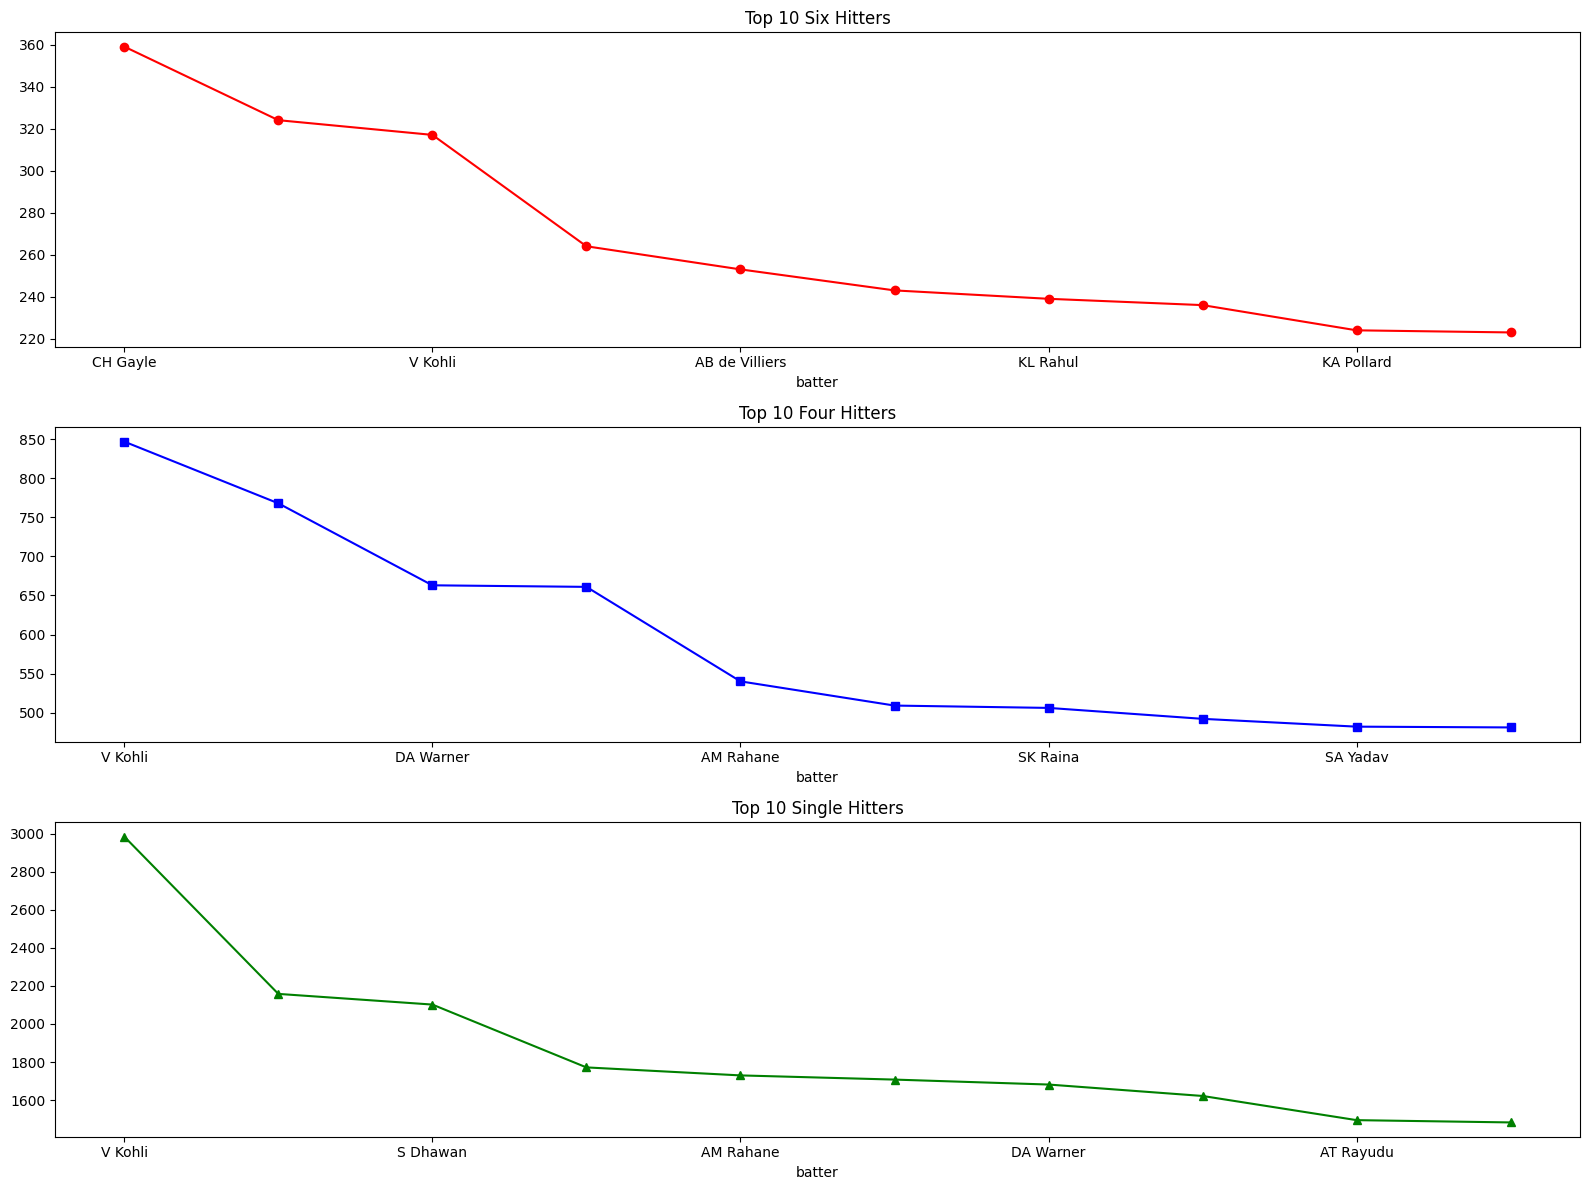

In [5]:
most_sixes = d_df.groupby("batter")["is_boundary_6"].sum().sort_values(ascending=False).head(10)
most_fours = d_df.groupby("batter")["is_boundary_4"].sum().sort_values(ascending=False).head(10)
most_singles = d_df.groupby("batter")["is_single"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(3,1, figsize=(16,12))
most_sixes.plot(kind="line", ax=ax[0], color="red" , marker="o")
ax[0].set_title("Top 10 Six Hitters")
most_fours.plot(kind="line", ax=ax[1], color="blue", marker="s")
ax[1].set_title("Top 10 Four Hitters")
most_singles.plot(kind="line", ax=ax[2], color="green", marker="^")
ax[2].set_title("Top 10 Single Hitters")
plt.tight_layout()
plt.show()


In [6]:
matches_df["chasing_win"] = (
    matches_df["winner"]
    ==
    matches_df["team_batting_second"]
)

In [7]:
inning_table = (d_df.groupby(
    ["match_id", "inning" , "batting_team"]).agg(
        score = ("batter_runs", "sum"),
        wickets = ("is_wicket", "sum"),
        fours = ("is_boundary_4", "sum"),
        sixes = ("is_boundary_6", "sum"),
        extras=("extras", "sum"),
        dot_balls = ("is_dot_ball", "sum")
    ).reset_index())


inning_table.to_csv(r"C:\Users\mayan\gitrepos\Dashboards\inning_table.csv", index=False)

In [8]:
matches_innings = matches_df.merge(inning_table, on="match_id", how="left")
stadium_info = matches_innings.groupby("venue").agg(
    matches = ("match_id", "nunique"),
    cities = ("city", lambda x: x.mode()[0] if not x.mode().empty else None),
    total_innings = ("match_id", "count"),
    total_runs = ("score", "sum"),
    average_score = ("score", "mean"),
    average_wickets = ("wickets", "mean"),
    highest_score = ("score", "max"),
    total_wickets = ("wickets", "sum"),
    total_fours = ("fours", "sum"),
    total_sixes = ("sixes", "sum")

)
stadium_info["batting_index"] = stadium_info["average_score"] / stadium_info["average_score"].max() *100
stadium_info["bowling_index"] = stadium_info["average_wickets"] / stadium_info["average_score"] *100
stadium_info["boundary_rate"] = (stadium_info["total_fours"] + stadium_info["total_sixes"]) / stadium_info["total_runs"]
stadium_info["six_per_inning"] = stadium_info["total_sixes"] / stadium_info["total_innings"]
stadium_info["wickets_per_inning"] = (stadium_info["total_wickets"]/stadium_info["total_innings"])
avg_first_innings = matches_innings[matches_innings["inning"] == 1].groupby("venue")["score"].mean().round(2).sort_values(ascending=False)
avg_second_innings = matches_innings[matches_innings["inning"] == 2].groupby("venue")["score"].mean().round(2).sort_values(ascending=False)

chasing_success_rate = (
    matches_df
    .groupby("venue")["chasing_win"]
    .mean()
    * 100
)
avg_first_innings = (
    matches_innings[matches_innings["inning"] == 1].groupby("venue")["score"].mean().round(2).rename("average_first_innings")
)

avg_second_innings = (
    matches_innings[matches_innings["inning"] == 2].groupby("venue")["score"].mean().round(2).rename("average_second_innings")
)
stadium_info = stadium_info.join(chasing_success_rate, on="venue")
stadium_info = stadium_info.join(avg_first_innings)
stadium_info = stadium_info.join(avg_second_innings)
stadium_info["chasing_score_gap"]  = stadium_info["average_second_innings"] - stadium_info["average_first_innings"]
stadium_info.head()

,matches,cities,total_innings,total_runs,average_score,average_wickets,highest_score,total_wickets,total_fours,total_sixes,batting_index,bowling_index,boundary_rate,six_per_inning,wickets_per_inning,chasing_win,average_first_innings,average_second_innings,chasing_score_gap
venue,,,,,,,,,,,,,,,,,,,
Arun Jaitley Stadium,30,Delhi,62,10754,173.451613,5.629032,261,349,977,566,100.000000,3.245304,0.143481,9.129032,5.629032,53.333333,185.03,172.67,-12.36
Eden Gardens,30,Kolkata,59,10206,172.983051,5.966102,256,352,941,553,99.729860,3.448952,0.146384,9.372881,5.966102,43.333333,180.47,165.24,-15.23
M Chinnaswamy Stadium,39,Bengaluru,78,13397,171.756410,6.141026,272,479,1125,734,99.022665,3.575427,0.138762,9.410256,6.141026,51.282051,175.85,167.67,-8.18
MA Chidambaram Stadium,89,Chennai,182,27084,148.813187,5.950549,240,1083,2345,1026,85.795217,3.998671,0.124465,5.637363,5.950549,44.943820,158.18,145.80,-12.38
Rajiv Gandhi International Stadium,75,Hyderabad,151,23357,154.682119,5.708609,268,862,2120,950,89.178830,3.690542,0.131438,6.291391,5.708609,54.666667,161.76,151.23,-10.53


In [10]:
d_df

,match_id,inning,batting_team,phase,phase_id,over,ball,batter,bowler,non_striker,...,legbye_runs,is_legal_delivery,is_dot_ball,is_single,is_boundary_4,is_boundary_6,is_wicket,dismissal_type,player_out,fielder
0,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,1,DA Warner,TS Mills,S Dhawan,...,0,1,1,0,0,0,0,NaN,NaN,NaN
1,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,2,DA Warner,TS Mills,S Dhawan,...,0,1,1,0,0,0,0,NaN,NaN,NaN
2,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,3,DA Warner,TS Mills,S Dhawan,...,0,1,0,0,1,0,0,NaN,NaN,NaN
3,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,4,DA Warner,TS Mills,S Dhawan,...,0,1,1,0,0,0,0,NaN,NaN,NaN
4,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,5,DA Warner,TS Mills,S Dhawan,...,0,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295727,981019,2,Royal Challengers Bengaluru,Death,3,19,2,Sachin Baby,B Kumar,CJ Jordan,...,0,1,0,0,0,0,0,NaN,NaN,NaN
295728,981019,2,Royal Challengers Bengaluru,Death,3,19,3,Sachin Baby,B Kumar,CJ Jordan,...,0,1,1,0,0,0,1,run out,CJ Jordan,NV Ojha
295729,981019,2,Royal Challengers Bengaluru,Death,3,19,4,Iqbal Abdulla,B Kumar,Sachin Baby,...,1,1,0,0,0,0,0,NaN,NaN,NaN
295730,981019,2,Royal Challengers Bengaluru,Death,3,19,5,Sachin Baby,B Kumar,Iqbal Abdulla,...,0,1,0,1,0,0,0,NaN,NaN,NaN


In [ ]:
batter_summary = d_df.groupby("batter").agg(
    runs = ("batter_runs", "sum"),
    balls_faced = ("ball", "sum"),
    dots = ("is_dot_ball" , "sum"),
    fours = ("is_boundary_4", "sum"),
    sixes = ("is_boundary_6", "sum"),
    singles = ("is_single", "sum")

)
batter_summary["strike_rate"] = (batter_summary["runs"] / batter_summary["balls_faced"]) * 100
batter_summary = batter_summary.sort_values(by="runs", ascending=False)
batter_summary

KeyError: "Column(s) ['batter_balls_faced', 'batter_fours', 'batter_sixes'] do not exist"

In [ ]:
matches_df["team1"].unique()

array(['Sunrisers Hyderabad', 'Rising Pune Supergiant', 'Gujarat Lions',
       'Kings XI Punjab', 'Royal Challengers Bangalore', 'Mumbai Indians',
       'Kolkata Knight Riders', 'Delhi Daredevils', 'Rajasthan Royals',
       'Chennai Super Kings', 'Delhi Capitals', 'Punjab Kings',
       'Lucknow Super Giants', 'Gujarat Titans',
       'Royal Challengers Bengaluru', 'Deccan Chargers',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Rising Pune Supergiants'],
      dtype=object)

In [ ]:
matches_df["venue"].unique()

array(['Rajiv Gandhi International Stadium, Uppal',
       'Maharashtra Cricket Association Stadium',
       'Saurashtra Cricket Association Stadium', 'Holkar Cricket Stadium',
       'M.Chinnaswamy Stadium', 'Wankhede Stadium', 'Eden Gardens',
       'M Chinnaswamy Stadium', 'Feroz Shah Kotla',
       'Punjab Cricket Association IS Bindra Stadium, Mohali',
       'Green Park', 'Punjab Cricket Association IS Bindra Stadium',
       'Rajiv Gandhi International Stadium', 'MA Chidambaram Stadium',
       'Sawai Mansingh Stadium', 'Arun Jaitley Stadium',
       'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
       'Sheikh Zayed Stadium', 'Dubai International Cricket Stadium',
       'Sharjah Cricket Stadium',
       'MA Chidambaram Stadium, Chepauk, Chennai',
       'Wankhede Stadium, Mumbai', 'Narendra Modi Stadium, Ahmedabad',
       'Arun Jaitley Stadium, Delhi', 'Zayed Cricket Stadium, Abu Dhabi',
       'Brabourne Stadium, Mumbai', 'Dr DY Patil Sports Academy, Mumbai',
       

In [ ]:
d_df.head()

,match_id,inning,batting_team,phase,phase_id,over,ball,batter,bowler,non_striker,...,legbye_runs,is_legal_delivery,is_dot_ball,is_single,is_boundary_4,is_boundary_6,is_wicket,dismissal_type,player_out,fielder
0,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,1,DA Warner,TS Mills,S Dhawan,...,0,1,1,0,0,0,0,NaN,NaN,NaN
1,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,2,DA Warner,TS Mills,S Dhawan,...,0,1,1,0,0,0,0,NaN,NaN,NaN
2,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,3,DA Warner,TS Mills,S Dhawan,...,0,1,0,0,1,0,0,NaN,NaN,NaN
3,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,4,DA Warner,TS Mills,S Dhawan,...,0,1,1,0,0,0,0,NaN,NaN,NaN
4,1082591,1,Sunrisers Hyderabad,Powerplay,1,0,5,DA Warner,TS Mills,S Dhawan,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [ ]:
matches_df.head()

,match_id,season,match_number,date,city,venue,team1,team2,team_batting_first,team_batting_second,...,toss_decision,winner,result_type,result_margin,win_by_runs,win_by_wickets,player_of_match,match_type,overs,balls_per_over
0,1082591,2017,NaN,2017-04-05,Hyderabad,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,Royal Challengers Bangalore,...,field,Sunrisers Hyderabad,Runs,35.0,35,0,Yuvraj Singh,T20,20,6
1,1082592,2017,NaN,2017-04-06,Pune,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Mumbai Indians,Mumbai Indians,Rising Pune Supergiant,...,field,Rising Pune Supergiant,Wickets,7.0,0,7,SPD Smith,T20,20,6
2,1082593,2017,NaN,2017-04-07,Rajkot,Saurashtra Cricket Association Stadium,Gujarat Lions,Kolkata Knight Riders,Gujarat Lions,Kolkata Knight Riders,...,field,Kolkata Knight Riders,Wickets,10.0,0,10,CA Lynn,T20,20,6
3,1082594,2017,NaN,2017-04-08,Indore,Holkar Cricket Stadium,Kings XI Punjab,Rising Pune Supergiant,Rising Pune Supergiant,Kings XI Punjab,...,field,Kings XI Punjab,Wickets,6.0,0,6,GJ Maxwell,T20,20,6
4,1082595,2017,NaN,2017-04-08,Bengaluru,M.Chinnaswamy Stadium,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,Delhi Daredevils,...,bat,Royal Challengers Bangalore,Runs,15.0,15,0,KM Jadhav,T20,20,6


In [ ]:
matches_df.isnull().sum()

match_id                  0
season                    0
match_number           1243
date                      0
city                     51
venue                     0
team1                     0
team2                     0
team_batting_first        0
team_batting_second       0
toss_winner               0
toss_decision             0
winner                   25
result_type               0
result_margin            25
win_by_runs               0
win_by_wickets            0
player_of_match           9
match_type                0
overs                     0
balls_per_over            0
dtype: int64